# 🌸 Self-Supervised Image Representation Learning using Masked Autoencoders (MAE)

This notebook implements a **Masked Autoencoder (MAE)** from scratch using base PyTorch layers.  
The model learns to reconstruct images after masking 75% of the input patches — no labels needed!

**Architecture:**
- 🔷 **Encoder**: ViT-Base (B/16) — ~86M parameters, processes only 25% visible patches
- 🔹 **Decoder**: ViT-Small (S/16) — ~22M parameters, reconstructs full image

**Dataset**: TinyImageNet (64×64 images, upsampled to 224×224)

## 📦 Step 1: Install Dependencies

In [2]:
# Install required libraries (Kaggle already has most, we just need gradio)
!pip install gradio -q
!pip install scikit-image -q


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## 📚 Step 2: Import Libraries

In [3]:
import os
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
import torchvision.transforms as transforms

# PyTorch/XLA — TPU support
import torch_xla
import torch_xla.core.xla_model as xm
import torch_xla.distributed.parallel_loader as pl

from skimage.metrics import peak_signal_noise_ratio as psnr_fn
from skimage.metrics import structural_similarity as ssim_fn

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device — TPU core
device = xm.xla_device()
print(f'Using device: {device}')
print(f'XLA device type: {xm.xla_device_hw(device)}')


/usr/local/lib/python3.12/site-packages/torch_xla/__init__.py:258: UserWarning: `tensorflow` can conflict with `torch-xla`. Prefer `tensorflow-cpu` when using PyTorch/XLA. To silence this warning, `pip uninstall -y tensorflow && pip install tensorflow-cpu`. If you are in a notebook environment such as Colab or Kaggle, restart your notebook runtime afterwards.
  warnings.warn(
/tmp/ipykernel_12/3684590884.py:33: DeprecationWarning: Use torch_xla.device instead
  device = xm.xla_device()
E0000 00:00:1772748522.921804      12 common_lib.cc:648] Could not set metric server port: INVALID_ARGUMENT: Could not find SliceBuilder port 8471 in any of the 0 ports provided in `tpu_process_addresses`="local"
=== Source Location Trace: === 
learning/45eac/tfrc/runtime/common_lib.cc:238


Using device: xla:0
XLA device type: TPU


## 🗂️ Step 3: Dataset — TinyImageNet

In [4]:
# ── TinyImageNet paths (Kaggle dataset mount path) ──
TINY_IMAGENET_PATH = '/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200'

# Image config
IMAGE_SIZE   = 224
PATCH_SIZE   = 16
NUM_PATCHES  = (IMAGE_SIZE // PATCH_SIZE) ** 2   # 196
MASK_RATIO   = 0.75
NUM_VISIBLE  = int(NUM_PATCHES * (1 - MASK_RATIO))   # 49
NUM_MASKED   = NUM_PATCHES - NUM_VISIBLE              # 147

print(f'Total patches  : {NUM_PATCHES}')
print(f'Visible patches: {NUM_VISIBLE}')
print(f'Masked patches : {NUM_MASKED}')

# ── Transforms ──
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])


# ── Custom TinyImageNet Dataset ──
class TinyImageNetDataset(Dataset):
    """Loads TinyImageNet images for self-supervised MAE training."""

    def __init__(self, root, split='train', transform=None):
        self.transform = transform
        self.image_paths = []

        if split == 'train':
            train_dir = Path(root) / 'train'
            for class_dir in sorted(train_dir.iterdir()):
                img_dir = class_dir / 'images'
                if img_dir.exists():
                    for img_path in img_dir.glob('*.JPEG'):
                        self.image_paths.append(img_path)
        else:
            val_dir = Path(root) / 'val' / 'images'
            if val_dir.exists():
                for img_path in val_dir.glob('*.JPEG'):
                    self.image_paths.append(img_path)

        print(f'[{split}] Found {len(self.image_paths)} images')

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img


# Build datasets & loaders
BATCH_SIZE = 64
NUM_WORKERS = 2

train_dataset = TinyImageNetDataset(TINY_IMAGENET_PATH, split='train',
                                    transform=train_transform)
val_dataset   = TinyImageNetDataset(TINY_IMAGENET_PATH, split='val',
                                     transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS,
                          pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS,
                          pin_memory=True, drop_last=False)

print(f'Train batches: {len(train_loader)}')
print(f'Val   batches: {len(val_loader)}')

Total patches  : 196
Visible patches: 49
Masked patches : 147
[train] Found 100000 images
[val] Found 10000 images
Train batches: 1562
Val   batches: 157


## 🧩 Step 4: Patchification & Masking Utilities

In [5]:
def patchify(images, patch_size=PATCH_SIZE):
    """
    Split images into non-overlapping patches.
    Input : (B, 3, H, W)
    Output: (B, num_patches, patch_size*patch_size*3)
    """
    B, C, H, W = images.shape
    assert H % patch_size == 0 and W % patch_size == 0

    h = H // patch_size   # patches along height
    w = W // patch_size   # patches along width

    # Reshape: (B, C, h, patch_size, w, patch_size)
    x = images.reshape(B, C, h, patch_size, w, patch_size)
    # Permute: (B, h, w, patch_size, patch_size, C)
    x = x.permute(0, 2, 4, 3, 5, 1)
    # Flatten patch pixels: (B, h*w, patch_size*patch_size*C)
    x = x.reshape(B, h * w, patch_size * patch_size * C)
    return x


def unpatchify(patches, patch_size=PATCH_SIZE, image_size=IMAGE_SIZE):
    """
    Reconstruct image from patches.
    Input : (B, num_patches, patch_size*patch_size*3)
    Output: (B, 3, H, W)
    """
    B, N, D = patches.shape
    h = w = image_size // patch_size
    C = D // (patch_size * patch_size)

    x = patches.reshape(B, h, w, patch_size, patch_size, C)
    x = x.permute(0, 5, 1, 3, 2, 4)  # (B, C, h, patch_size, w, patch_size)
    x = x.reshape(B, C, h * patch_size, w * patch_size)
    return x


def random_masking(x, mask_ratio=MASK_RATIO):
    """
    Randomly mask patches, keeping (1 - mask_ratio) fraction visible.

    Input : x  — (B, N, D)  all patch embeddings
    Returns:
        x_visible    — (B, num_visible, D)
        mask         — (B, N)  bool: True = masked
        ids_restore  — (B, N)  indices to restore original order
    """
    B, N, D = x.shape
    num_keep = int(N * (1 - mask_ratio))

    # Random noise for shuffling
    noise = torch.rand(B, N, device=x.device)

    # Sort by noise — ids_shuffle[b] gives ascending-noise patch indices
    ids_shuffle = torch.argsort(noise, dim=1)
    ids_restore  = torch.argsort(ids_shuffle, dim=1)

    # Keep the first num_keep patches (lowest noise = "selected visible")
    ids_keep   = ids_shuffle[:, :num_keep]
    x_visible  = torch.gather(x, dim=1,
                               index=ids_keep.unsqueeze(-1).expand(-1, -1, D))

    # Build binary mask (0 = visible, 1 = masked) — shape (B, N)
    mask = torch.ones(B, N, device=x.device)
    mask[:, :num_keep] = 0
    mask = torch.gather(mask, dim=1, index=ids_restore)  # unshuffle mask

    return x_visible, mask, ids_restore


print('Patchify / unpatchify / masking functions defined ✓')

# Quick sanity check
dummy = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE)
patches = patchify(dummy)
print(f'  Image shape   : {dummy.shape}')
print(f'  Patches shape : {patches.shape}')   # (2, 196, 768)
recon = unpatchify(patches)
print(f'  Recon shape   : {recon.shape}')      # (2, 3, 224, 224)
assert torch.allclose(dummy, recon, atol=1e-5), 'Patchify/unpatchify round-trip failed!'
print('  Round-trip test passed ✓')

Patchify / unpatchify / masking functions defined ✓
  Image shape   : torch.Size([2, 3, 224, 224])
  Patches shape : torch.Size([2, 196, 768])
  Recon shape   : torch.Size([2, 3, 224, 224])
  Round-trip test passed ✓


## 🔷 Step 5: MAE Encoder — ViT-Base (B/16)

In [6]:
# ─────────────────────────────────────────────
#  Building blocks: Multi-Head Attention & MLP
# ─────────────────────────────────────────────

class MultiHeadSelfAttention(nn.Module):
    """Vanilla multi-head self-attention with optional dropout."""

    def __init__(self, embed_dim, num_heads, attn_drop=0.0, proj_drop=0.0):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim  = embed_dim // num_heads
        self.scale     = self.head_dim ** -0.5

        self.qkv  = nn.Linear(embed_dim, embed_dim * 3, bias=True)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x):
        B, N, C = x.shape
        # QKV projection
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # (3, B, heads, N, head_dim)
        q, k, v = qkv.unbind(0)

        # Scaled dot-product attention
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x


class MLP(nn.Module):
    """Two-layer feed-forward network with GELU activation."""

    def __init__(self, in_dim, hidden_dim, out_dim, drop=0.0):
        super().__init__()
        self.fc1  = nn.Linear(in_dim, hidden_dim)
        self.act  = nn.GELU()
        self.fc2  = nn.Linear(hidden_dim, out_dim)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        return self.drop(self.fc2(self.drop(self.act(self.fc1(x)))))


class TransformerBlock(nn.Module):
    """Pre-norm transformer block (Attention → MLP)."""

    def __init__(self, embed_dim, num_heads, mlp_ratio=4.0,
                 attn_drop=0.0, proj_drop=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = MultiHeadSelfAttention(embed_dim, num_heads,
                                             attn_drop, proj_drop)
        self.norm2 = nn.LayerNorm(embed_dim)
        hidden     = int(embed_dim * mlp_ratio)
        self.mlp   = MLP(embed_dim, hidden, embed_dim, proj_drop)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


# ─────────────────────────────────────────────
#  Sinusoidal / Learnable Positional Embeddings
# ─────────────────────────────────────────────

def get_2d_sincos_pos_embed(embed_dim, grid_size):
    """
    Generate 2-D sinusoidal positional embeddings.
    Returns: (grid_size*grid_size, embed_dim)
    """
    assert embed_dim % 2 == 0
    half = embed_dim // 2

    # 1-D sincos embedding
    omega = np.arange(half // 2, dtype=np.float32)
    omega /= half // 2
    omega  = 1.0 / (10000 ** omega)  # (half//2,)

    pos = np.arange(grid_size, dtype=np.float32)  # (grid_size,)
    out = np.einsum('i,j->ij', pos, omega)         # (grid_size, half//2)

    emb_sin = np.sin(out)
    emb_cos = np.cos(out)
    emb_1d  = np.concatenate([emb_sin, emb_cos], axis=1)  # (grid_size, half)

    # 2-D: combine row & col embeddings
    emb_h = np.repeat(emb_1d, grid_size, axis=0)          # (g*g, half)
    emb_w = np.tile(emb_1d, (grid_size, 1))               # (g*g, half)
    emb   = np.concatenate([emb_h, emb_w], axis=1)        # (g*g, embed_dim)
    return torch.from_numpy(emb).float()


# ─────────────────────────────────────────────
#  MAE Encoder  (ViT-Base B/16)
# ─────────────────────────────────────────────

class MAEEncoder(nn.Module):
    """
    ViT-Base encoder for MAE.
    • Receives only visible patches (25%).
    • Patch embedding → add pos-embed → Transformer blocks → LayerNorm.
    """

    def __init__(
        self,
        image_size  = IMAGE_SIZE,
        patch_size  = PATCH_SIZE,
        in_channels = 3,
        embed_dim   = 768,
        depth       = 12,
        num_heads   = 12,
        mlp_ratio   = 4.0,
    ):
        super().__init__()
        self.patch_size  = patch_size
        self.embed_dim   = embed_dim
        self.num_patches = (image_size // patch_size) ** 2

        patch_dim = in_channels * patch_size * patch_size  # 3*16*16 = 768

        # Linear projection of flattened patches
        self.patch_embed = nn.Linear(patch_dim, embed_dim)

        # CLS token
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        # Fixed 2-D sincos positional embeddings (not learned, not updated)
        grid_size = image_size // patch_size
        pos_embed = get_2d_sincos_pos_embed(embed_dim, grid_size)  # (N, D)
        # +1 for cls token
        cls_pos = torch.zeros(1, embed_dim)
        pos_embed = torch.cat([cls_pos, pos_embed], dim=0).unsqueeze(0)  # (1, N+1, D)
        self.register_buffer('pos_embed', pos_embed)

        # Transformer blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

        self._init_weights()

    def _init_weights(self):
        # Initialize patch embedding & cls token
        nn.init.xavier_uniform_(self.patch_embed.weight)
        nn.init.normal_(self.cls_token, std=0.02)

    def forward(self, x, mask_ratio=MASK_RATIO):
        """
        x: (B, 3, H, W) raw images
        Returns:
            latent     — (B, num_visible+1, D)  encoder output (includes CLS)
            mask       — (B, N)  1=masked, 0=visible
            ids_restore — (B, N)  for restoring order in decoder
        """
        B = x.shape[0]

        # 1. Patchify & embed
        patches = patchify(x, self.patch_size)            # (B, N, patch_dim)
        tokens  = self.patch_embed(patches)               # (B, N, embed_dim)

        # 2. Add positional embeddings (skip cls pos at index 0)
        tokens = tokens + self.pos_embed[:, 1:, :]        # (B, N, D)

        # 3. Random masking — keep only visible tokens
        tokens_vis, mask, ids_restore = random_masking(tokens, mask_ratio)

        # 4. Prepend CLS token (with its positional embedding)
        cls = self.cls_token.expand(B, -1, -1)            # (B, 1, D)
        cls = cls + self.pos_embed[:, :1, :]              # add cls pos embed
        tokens_vis = torch.cat([cls, tokens_vis], dim=1)  # (B, 1+num_vis, D)

        # 5. Transformer blocks
        for block in self.blocks:
            tokens_vis = block(tokens_vis)
        latent = self.norm(tokens_vis)

        return latent, mask, ids_restore


# Parameter count
enc = MAEEncoder()
enc_params = sum(p.numel() for p in enc.parameters()) / 1e6
print(f'MAE Encoder parameters: {enc_params:.1f}M')  # ~86M
del enc

MAE Encoder parameters: 85.6M


## 🔹 Step 6: MAE Decoder — ViT-Small (S/16)

In [7]:
class MAEDecoder(nn.Module):
    """
    Lightweight ViT-Small decoder for MAE.
    • Projects encoder latents to decoder dimension.
    • Inserts learnable mask tokens for missing patches.
    • Runs Transformer blocks over the full sequence.
    • Projects each token back to pixel space.
    """

    def __init__(
        self,
        num_patches   = NUM_PATCHES,
        patch_size    = PATCH_SIZE,
        encoder_dim   = 768,
        decoder_dim   = 384,
        depth         = 12,
        num_heads     = 6,
        mlp_ratio     = 4.0,
        image_size    = IMAGE_SIZE,
        in_channels   = 3,
    ):
        super().__init__()
        self.decoder_dim  = decoder_dim
        self.num_patches  = num_patches
        patch_dim = in_channels * patch_size * patch_size  # output size per patch

        # Project encoder dim → decoder dim
        self.encoder_to_decoder = nn.Linear(encoder_dim, decoder_dim, bias=True)

        # Learnable mask token
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_dim))

        # Fixed positional embeddings for decoder (full sequence including cls)
        grid_size = image_size // patch_size
        pos_embed = get_2d_sincos_pos_embed(decoder_dim, grid_size)  # (N, D)
        cls_pos   = torch.zeros(1, decoder_dim)
        pos_embed = torch.cat([cls_pos, pos_embed], dim=0).unsqueeze(0)  # (1, N+1, D)
        self.register_buffer('decoder_pos_embed', pos_embed)

        # Transformer blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(decoder_dim, num_heads, mlp_ratio)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(decoder_dim)

        # Linear head: project each token → patch pixels
        self.head = nn.Linear(decoder_dim, patch_dim, bias=True)

        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.mask_token, std=0.02)
        nn.init.xavier_uniform_(self.encoder_to_decoder.weight)
        nn.init.xavier_uniform_(self.head.weight)

    def forward(self, latent, ids_restore):
        """
        latent     : (B, 1+num_vis, encoder_dim)  — encoder output with CLS
        ids_restore: (B, N)  — indices to restore original patch order
        Returns    : pred  (B, N, patch_dim)
        """
        B = latent.shape[0]
        N = self.num_patches

        # 1. Project to decoder dimension
        x = self.encoder_to_decoder(latent)   # (B, 1+num_vis, decoder_dim)

        # 2. Expand mask tokens to fill missing positions
        num_vis  = x.shape[1] - 1             # subtract CLS
        num_mask = N - num_vis
        mask_tokens = self.mask_token.expand(B, num_mask, -1)   # (B, num_mask, D)

        # 3. Concatenate visible tokens (no CLS) + mask tokens,
        #    then restore original patch ordering
        x_no_cls  = x[:, 1:, :]              # (B, num_vis, D)
        x_full    = torch.cat([x_no_cls, mask_tokens], dim=1)  # (B, N, D)
        x_full    = torch.gather(
            x_full, dim=1,
            index=ids_restore.unsqueeze(-1).expand(-1, -1, self.decoder_dim)
        )                                     # (B, N, D)  — original order

        # 4. Prepend CLS token, add positional embeddings
        cls_token  = x[:, :1, :]             # (B, 1, D)
        x_full     = torch.cat([cls_token, x_full], dim=1)   # (B, N+1, D)
        x_full     = x_full + self.decoder_pos_embed          # add pos embed

        # 5. Transformer blocks
        for block in self.blocks:
            x_full = block(x_full)
        x_full = self.norm(x_full)

        # 6. Prediction head (drop CLS)
        pred = self.head(x_full[:, 1:, :])   # (B, N, patch_dim)
        return pred


dec = MAEDecoder()
dec_params = sum(p.numel() for p in dec.parameters()) / 1e6
print(f'MAE Decoder parameters: {dec_params:.1f}M')  # ~22M
del dec

MAE Decoder parameters: 21.9M


## 🌟 Step 7: Full MAE Model

In [8]:
class MaskedAutoencoder(nn.Module):
    """Complete MAE wrapping encoder + decoder."""

    def __init__(
        self,
        image_size     = IMAGE_SIZE,
        patch_size     = PATCH_SIZE,
        encoder_dim    = 768,
        encoder_depth  = 12,
        encoder_heads  = 12,
        decoder_dim    = 384,
        decoder_depth  = 12,
        decoder_heads  = 6,
        mask_ratio     = MASK_RATIO,
    ):
        super().__init__()
        self.mask_ratio = mask_ratio
        self.patch_size = patch_size

        self.encoder = MAEEncoder(
            image_size  = image_size,
            patch_size  = patch_size,
            embed_dim   = encoder_dim,
            depth       = encoder_depth,
            num_heads   = encoder_heads,
        )
        self.decoder = MAEDecoder(
            num_patches  = (image_size // patch_size) ** 2,
            patch_size   = patch_size,
            encoder_dim  = encoder_dim,
            decoder_dim  = decoder_dim,
            depth        = decoder_depth,
            num_heads    = decoder_heads,
            image_size   = image_size,
        )

    def forward(self, x, mask_ratio=None):
        if mask_ratio is None:
            mask_ratio = self.mask_ratio
        latent, mask, ids_restore = self.encoder(x, mask_ratio)
        pred = self.decoder(latent, ids_restore)
        return pred, mask

    def compute_loss(self, imgs, pred, mask):
        """
        MSE loss computed ONLY on masked patches.
        imgs : (B, 3, H, W)
        pred : (B, N, patch_dim)
        mask : (B, N)  1 = masked
        """
        target = patchify(imgs, self.patch_size)     # (B, N, patch_dim)

        # Normalize targets per-patch (mean/std) — as in original MAE paper
        mean   = target.mean(dim=-1, keepdim=True)
        var    = target.var(dim=-1, keepdim=True)
        target = (target - mean) / (var + 1e-6).sqrt()

        loss_per_patch = ((pred - target) ** 2).mean(dim=-1)  # (B, N)

        # Only average over masked patches
        loss = (loss_per_patch * mask).sum() / mask.sum()
        return loss


# Build model & move to device
model = MaskedAutoencoder()

# Wrap with DataParallel for dual-GPU Kaggle setup
if torch.cuda.device_count() > 1:
    print(f'Using DataParallel across {torch.cuda.device_count()} GPUs')
    model = nn.DataParallel(model)

model = model.to(device)

total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f'Total model parameters: {total_params:.1f}M')

# Forward pass test
dummy = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)
with torch.no_grad():
    core = model.module if isinstance(model, nn.DataParallel) else model
    pred, mask = core(dummy)
print(f'Prediction shape : {pred.shape}')   # (2, 196, 768)
print(f'Mask shape       : {mask.shape}')   # (2, 196)
del dummy

Total model parameters: 107.5M
Prediction shape : torch.Size([2, 196, 768])
Mask shape       : torch.Size([2, 196])


## 🏋️ Step 8: Training Setup

In [13]:
# ── Hyperparameters ──
NUM_EPOCHS    = 20
BASE_LR       = 1.5e-4   # as in MAE paper: lr = base_lr * batch_size / 256
WEIGHT_DECAY  = 0.05
WARMUP_EPOCHS = 5
GRAD_CLIP     = 1.0      # max gradient norm

# Effective LR scaled to batch size
eff_lr = BASE_LR * BATCH_SIZE / 256
print(f'Effective learning rate: {eff_lr:.6f}')

# ── Optimizer ──
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=eff_lr,
    betas=(0.9, 0.95),
    weight_decay=WEIGHT_DECAY,
)

# ── Cosine LR Scheduler with linear warmup ──
def get_lr(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, NUM_EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr)

# Note: torch.cuda.amp (mixed precision) is not used on TPU.
# PyTorch/XLA handles its own bfloat16 optimisations automatically.
print('Optimizer and scheduler ready ✓ (no AMP scaler needed on TPU)')


Effective learning rate: 0.000037
Optimizer and scheduler ready ✓ (no AMP scaler needed on TPU)


## 🚀 Step 9: Training Loop

In [14]:
import time


def train_one_epoch(model, loader, optimizer, epoch):
    model.train()
    total_loss = 0.0

    # Wrap loader with XLA's parallel loader so tensors are pre-loaded onto TPU
    xla_loader = pl.MpDeviceLoader(loader, device)

    for step, imgs in enumerate(xla_loader):
        optimizer.zero_grad(set_to_none=True)

        pred, mask = model(imgs)
        loss = model.compute_loss(imgs, pred, mask)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        # xm.optimizer_step replaces optimizer.step() on TPU and calls mark_step
        xm.optimizer_step(optimizer)

        total_loss += loss.item()

        if (step + 1) % 50 == 0:
            xm.mark_step()
            print(f'  Epoch {epoch+1} | Step {step+1}/{len(loader)} '
                  f'| Loss: {loss.item():.4f}')

    return total_loss / len(loader)


@torch.no_grad()
def validate(model, loader):
    model.eval()
    total_loss = 0.0

    xla_loader = pl.MpDeviceLoader(loader, device)

    for imgs in xla_loader:
        pred, mask = model(imgs)
        loss = model.compute_loss(imgs, pred, mask)
        total_loss += loss.item()

    xm.mark_step()
    return total_loss / len(loader)


# ── Main training loop ──
train_losses = []
val_losses   = []
best_val     = float('inf')

print('Starting training on TPU...\n')
for epoch in range(NUM_EPOCHS):
    t0 = time.time()

    train_loss = train_one_epoch(model, train_loader, optimizer, epoch)
    val_loss   = validate(model, val_loader)
    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    elapsed = time.time() - t0
    lr_now  = optimizer.param_groups[0]['lr']

    print(f'Epoch [{epoch+1:02d}/{NUM_EPOCHS}]  '
          f'Train Loss: {train_loss:.4f}  '
          f'Val Loss: {val_loss:.4f}  '
          f'LR: {lr_now:.6f}  '
          f'Time: {elapsed:.1f}s')

    # Save best checkpoint — move tensors to CPU before saving
    if val_loss < best_val:
        best_val = val_loss
        # xm.save handles TPU→CPU tensor movement safely
        xm.save(model.state_dict(), 'mae_best.pth')
        print(f'  ✨ New best model saved (val_loss={best_val:.4f})')

print('\nTraining complete!')


Starting training on TPU...



/tmp/ipykernel_12/3701427124.py:26: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()


  Epoch 1 | Step 50/1562 | Loss: 0.6701
  Epoch 1 | Step 100/1562 | Loss: 0.6693
  Epoch 1 | Step 150/1562 | Loss: 0.6729
  Epoch 1 | Step 200/1562 | Loss: 0.6181
  Epoch 1 | Step 250/1562 | Loss: 0.6815
  Epoch 1 | Step 300/1562 | Loss: 0.6448
  Epoch 1 | Step 350/1562 | Loss: 0.6273
  Epoch 1 | Step 400/1562 | Loss: 0.6541
  Epoch 1 | Step 450/1562 | Loss: 0.6784
  Epoch 1 | Step 500/1562 | Loss: 0.6684
  Epoch 1 | Step 550/1562 | Loss: 0.6445
  Epoch 1 | Step 600/1562 | Loss: 0.6706
  Epoch 1 | Step 650/1562 | Loss: 0.6051
  Epoch 1 | Step 700/1562 | Loss: 0.5916
  Epoch 1 | Step 750/1562 | Loss: 0.6401
  Epoch 1 | Step 800/1562 | Loss: 0.6007
  Epoch 1 | Step 850/1562 | Loss: 0.6615
  Epoch 1 | Step 900/1562 | Loss: 0.6408
  Epoch 1 | Step 950/1562 | Loss: 0.6450
  Epoch 1 | Step 1000/1562 | Loss: 0.5978
  Epoch 1 | Step 1050/1562 | Loss: 0.6480
  Epoch 1 | Step 1100/1562 | Loss: 0.6551
  Epoch 1 | Step 1150/1562 | Loss: 0.6231
  Epoch 1 | Step 1200/1562 | Loss: 0.6269
  Epoch 1 | 

/tmp/ipykernel_12/3701427124.py:45: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()


Epoch [01/20]  Train Loss: 0.6406  Val Loss: 0.6310  LR: 0.000015  Time: 579.3s
  ✨ New best model saved (val_loss=0.6310)
  Epoch 2 | Step 50/1562 | Loss: 0.6283
  Epoch 2 | Step 100/1562 | Loss: 0.6534
  Epoch 2 | Step 150/1562 | Loss: 0.6100
  Epoch 2 | Step 200/1562 | Loss: 0.6571
  Epoch 2 | Step 250/1562 | Loss: 0.6038
  Epoch 2 | Step 300/1562 | Loss: 0.6667
  Epoch 2 | Step 350/1562 | Loss: 0.6366
  Epoch 2 | Step 400/1562 | Loss: 0.5863
  Epoch 2 | Step 450/1562 | Loss: 0.6263
  Epoch 2 | Step 500/1562 | Loss: 0.6178
  Epoch 2 | Step 550/1562 | Loss: 0.6011
  Epoch 2 | Step 600/1562 | Loss: 0.6199
  Epoch 2 | Step 650/1562 | Loss: 0.5934
  Epoch 2 | Step 700/1562 | Loss: 0.5894
  Epoch 2 | Step 750/1562 | Loss: 0.5878
  Epoch 2 | Step 800/1562 | Loss: 0.5900
  Epoch 2 | Step 850/1562 | Loss: 0.5531
  Epoch 2 | Step 900/1562 | Loss: 0.5661
  Epoch 2 | Step 950/1562 | Loss: 0.6130
  Epoch 2 | Step 1000/1562 | Loss: 0.5757
  Epoch 2 | Step 1050/1562 | Loss: 0.5921
  Epoch 2 | Ste

## 📉 Step 10: Plot Training Loss

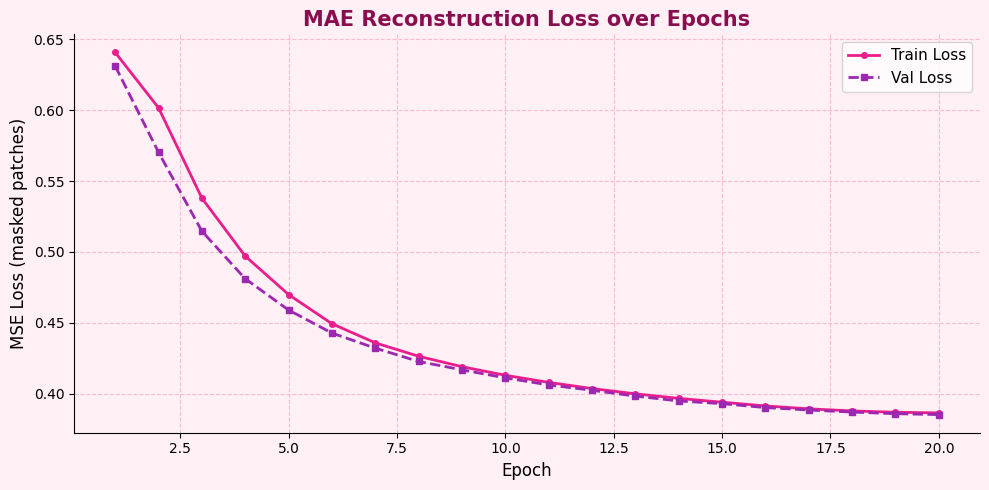

Loss curve saved to loss_curve.png


In [15]:
epochs_range = range(1, len(train_losses) + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs_range, train_losses, color='#E91E8C', linewidth=2,
        marker='o', markersize=4, label='Train Loss')
ax.plot(epochs_range, val_losses,   color='#9C27B0', linewidth=2,
        marker='s', markersize=4, label='Val Loss', linestyle='--')

ax.set_title('MAE Reconstruction Loss over Epochs', fontsize=15, fontweight='bold',
             color='#880E4F')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('MSE Loss (masked patches)', fontsize=12)
ax.legend(fontsize=11)
ax.set_facecolor('#FFF0F5')
fig.patch.set_facecolor('#FFF0F5')
ax.grid(True, color='#F8BBD0', linestyle='--', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150, bbox_inches='tight', facecolor='#FFF0F5')
plt.show()
print('Loss curve saved to loss_curve.png')

## 🎨 Step 11: Visualization — Masked Input, Reconstruction & Ground Truth

/tmp/ipykernel_12/4237111760.py:5: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()
/tmp/ipykernel_12/4237111760.py:42: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()


Loaded best checkpoint ✓


/tmp/ipykernel_12/4237111760.py:81: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12/4237111760.py:81: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12/4237111760.py:81: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12/4237111760.py:82: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  plt.savefig('reconstructions.png', dpi=150, bbox_inches='tight',
/tmp/ipykernel_12/4237111760.py:82: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing from font(s) DejaVu Sans.
  plt.savefig('reconstructions.png', dpi=150, bbox_inches='tight',
/tmp/ipykernel_12/4237111760.py:82: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.savefig('reconstructions.png', dpi=150, bbox_inches='tight',
/usr/local/lib/python3.12/site-package

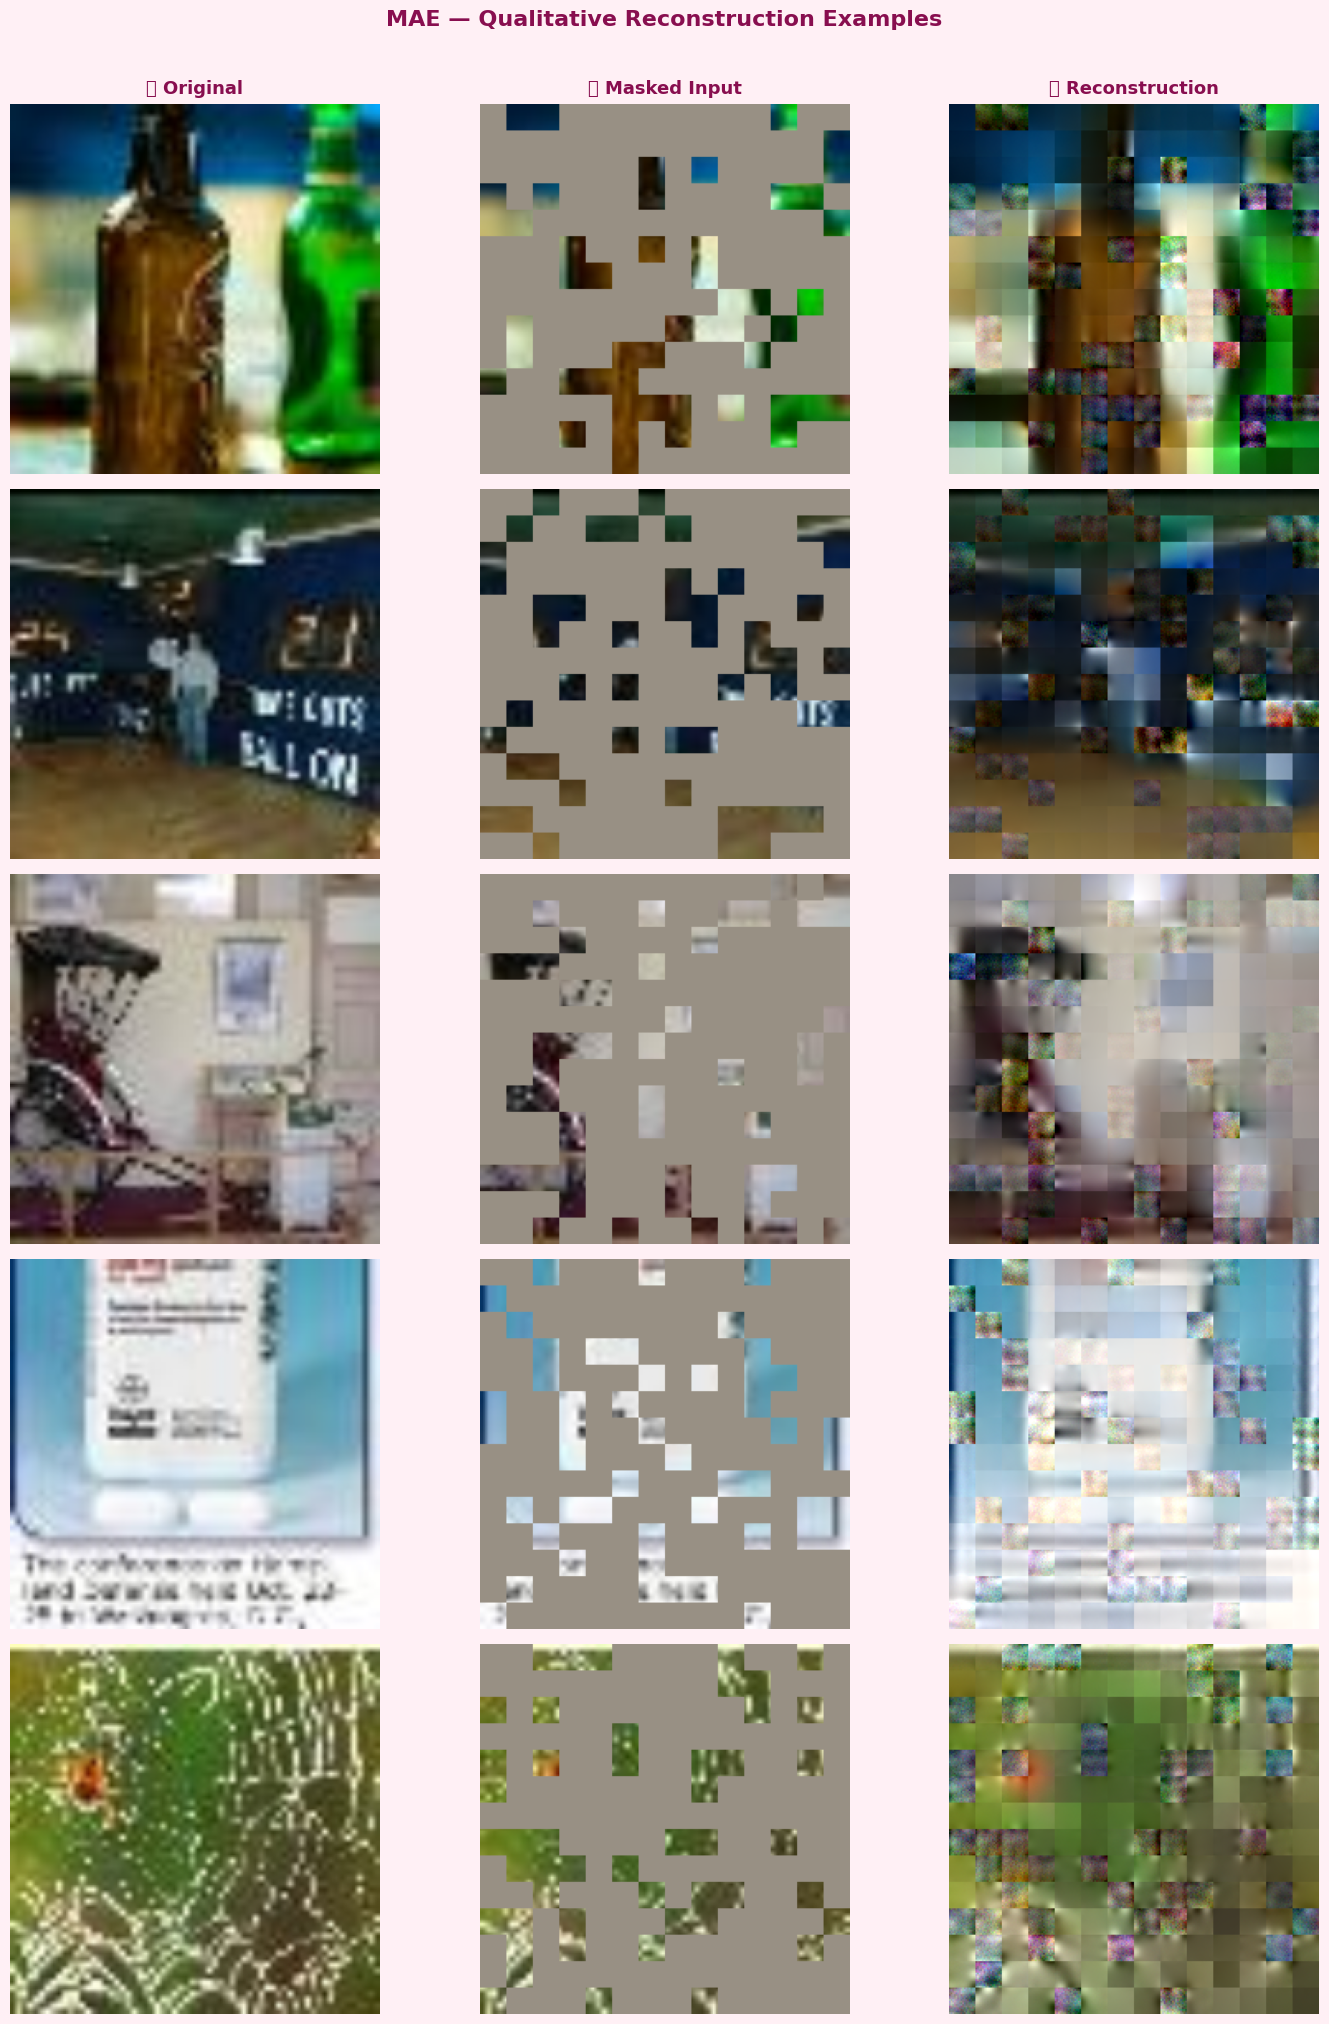

Reconstructions saved to reconstructions.png


In [17]:
# Load best checkpoint — load to CPU first, then send to TPU
state_dict = torch.load('mae_best.pth', map_location='cpu')
model.load_state_dict(state_dict)
model.to(device)
xm.mark_step()
print('Loaded best checkpoint ✓')


# ── Inverse normalisation helper ──
MEAN = torch.tensor([0.485, 0.456, 0.406])
STD  = torch.tensor([0.229, 0.224, 0.225])

def denorm(t):
    """(C,H,W) tensor → (H,W,C) numpy in [0,1]."""
    t = t.cpu().float()
    t = t * STD[:, None, None] + MEAN[:, None, None]
    return t.clamp(0, 1).permute(1, 2, 0).numpy()


def make_masked_image(img_tensor, mask):
    """
    Build an image showing which patches are masked (greyed out).
    img_tensor : (3, H, W)  normalised
    mask        : (N,)       1=masked
    """
    patches = patchify(img_tensor.unsqueeze(0)).squeeze(0)   # (N, D)
    masked  = patches.clone()
    masked[mask.bool()] = 0.5  # mid-grey in normalised space
    recon_t = unpatchify(masked.unsqueeze(0)).squeeze(0)     # (3, H, W)
    return denorm(recon_t)


@torch.no_grad()
def visualise_reconstructions(model, dataset, n_samples=5,
                               mask_ratio=MASK_RATIO):
    model.eval()

    indices = random.sample(range(len(dataset)), n_samples)
    imgs    = torch.stack([dataset[i] for i in indices]).to(device)

    pred, mask = model(imgs, mask_ratio)
    xm.mark_step()

    # Move to CPU for processing
    imgs_cpu = imgs.cpu()
    pred_cpu = pred.cpu()
    mask_cpu = mask.cpu()

    # Un-normalise predictions per-patch
    target_patches = patchify(imgs_cpu)
    patch_mean = target_patches.mean(dim=-1, keepdim=True)
    patch_std  = (target_patches.var(dim=-1, keepdim=True) + 1e-6).sqrt()
    pred_unnorm = pred_cpu * patch_std + patch_mean   # (B, N, D)

    fig = plt.figure(figsize=(15, 4 * n_samples))
    fig.patch.set_facecolor('#FFF0F5')

    titles = ['🖼 Original', '🎭 Masked Input', '✨ Reconstruction']
    cols   = 3

    for i in range(n_samples):
        orig_np   = denorm(imgs_cpu[i])
        masked_np = make_masked_image(imgs_cpu[i], mask_cpu[i])
        recon_img = unpatchify(pred_unnorm[i].unsqueeze(0)).squeeze(0)
        recon_np  = denorm(recon_img)

        for j, (img_np, title) in enumerate(
                zip([orig_np, masked_np, recon_np], titles)):
            ax = fig.add_subplot(n_samples, cols, i * cols + j + 1)
            ax.imshow(img_np)
            if i == 0:
                ax.set_title(title, fontsize=13, fontweight='bold',
                             color='#880E4F', pad=8)
            ax.axis('off')
            for sp in ax.spines.values():
                sp.set_edgecolor('#F48FB1')
                sp.set_linewidth(2)

    plt.suptitle('MAE — Qualitative Reconstruction Examples',
                 fontsize=16, fontweight='bold', color='#880E4F', y=1.01)
    plt.tight_layout()
    plt.savefig('reconstructions.png', dpi=150, bbox_inches='tight',
                facecolor='#FFF0F5')
    plt.show()
    print('Reconstructions saved to reconstructions.png')


visualise_reconstructions(model, val_dataset, n_samples=5)


## 📊 Step 12: Quantitative Evaluation — PSNR & SSIM

In [18]:
@torch.no_grad()
def evaluate_metrics(model, dataset, n_samples=100, mask_ratio=MASK_RATIO):
    """Compute average PSNR and SSIM on n_samples validation images."""
    model.eval()
    core = get_core(model)

    psnr_list = []
    ssim_list = []

    indices = random.sample(range(len(dataset)), min(n_samples, len(dataset)))

    for idx in indices:
        img = dataset[idx].unsqueeze(0).to(device)  # (1, 3, H, W)

        pred, mask = core(img, mask_ratio)

        # Undo per-patch normalisation
        target_patches = patchify(img)
        patch_mean = target_patches.mean(dim=-1, keepdim=True)
        patch_std  = (target_patches.var(dim=-1, keepdim=True) + 1e-6).sqrt()
        pred_unnorm = pred * patch_std + patch_mean

        orig_np  = denorm(img.squeeze(0).cpu())   # (H,W,3) [0,1]
        recon_t  = unpatchify(pred_unnorm).squeeze(0)
        recon_np = denorm(recon_t.cpu())           # (H,W,3) [0,1]

        psnr_val = psnr_fn(orig_np, recon_np, data_range=1.0)
        ssim_val = ssim_fn(orig_np, recon_np,
                           data_range=1.0, channel_axis=-1,
                           win_size=7)

        psnr_list.append(psnr_val)
        ssim_list.append(ssim_val)

    mean_psnr = np.mean(psnr_list)
    mean_ssim = np.mean(ssim_list)

    print('=' * 45)
    print(f'  Evaluation on {len(indices)} samples')
    print(f'  Mask ratio : {mask_ratio*100:.0f}%')
    print(f'  PSNR       : {mean_psnr:.2f} dB')
    print(f'  SSIM       : {mean_ssim:.4f}')
    print('=' * 45)

    return mean_psnr, mean_ssim


mean_psnr, mean_ssim = evaluate_metrics(model, val_dataset, n_samples=100)

KeyboardInterrupt: 

## 🌸 Step 13: Gradio App — Pretty & Interactive

In [19]:
import gradio as gr

# Make sure the best model is loaded
core = get_core(model)
core.eval()


# ── Inference function for Gradio ──
@torch.no_grad()
def mae_inference(pil_img, mask_ratio_pct):
    """
    pil_img       : PIL.Image uploaded by the user
    mask_ratio_pct: int  0–95  (percentage of patches to mask)
    Returns       : masked_pil, recon_pil, psnr_str, ssim_str
    """
    mask_ratio = float(mask_ratio_pct) / 100.0

    # Preprocess
    transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std =[0.229, 0.224, 0.225]),
    ])
    img_t = transform(pil_img.convert('RGB')).unsqueeze(0).to(device)

    pred, mask = core(img_t, mask_ratio)

    # Undo per-patch normalisation
    target_patches = patchify(img_t)
    patch_mean = target_patches.mean(dim=-1, keepdim=True)
    patch_std  = (target_patches.var(dim=-1, keepdim=True) + 1e-6).sqrt()
    pred_unnorm = pred * patch_std + patch_mean

    orig_np   = denorm(img_t.squeeze(0).cpu())
    masked_np = make_masked_image(img_t.squeeze(0).cpu(), mask.squeeze(0).cpu())
    recon_t   = unpatchify(pred_unnorm).squeeze(0)
    recon_np  = denorm(recon_t.cpu())

    # Metrics
    psnr_val = psnr_fn(orig_np, recon_np, data_range=1.0)
    ssim_val = ssim_fn(orig_np, recon_np,
                       data_range=1.0, channel_axis=-1, win_size=7)

    # Convert numpy arrays to PIL
    to_pil = lambda arr: Image.fromarray((arr * 255).astype(np.uint8))

    return (
        to_pil(orig_np),
        to_pil(masked_np),
        to_pil(recon_np),
        f'{psnr_val:.2f} dB',
        f'{ssim_val:.4f}',
    )


# ── Girly-themed Gradio UI ──
PINK_CSS = """
:root {
    --color-accent: #E91E8C;
    --color-accent-soft: #F8BBD0;
    --color-bg: #FFF0F5;
    --color-body-text: #4A0030;
}
body, .gradio-container {
    background: linear-gradient(135deg, #FFF0F5 0%, #FCE4EC 100%) !important;
    font-family: 'Segoe UI', sans-serif;
}
.gr-button {
    background: linear-gradient(90deg, #E91E8C, #9C27B0) !important;
    color: white !important;
    border-radius: 25px !important;
    font-weight: bold !important;
    font-size: 15px !important;
    border: none !important;
    padding: 10px 28px !important;
    box-shadow: 0 3px 10px rgba(233,30,140,0.4) !important;
}
.gr-button:hover {
    opacity: 0.9;
    transform: scale(1.03);
    transition: all 0.2s;
}
.label-wrap, label {
    color: #880E4F !important;
    font-weight: 600 !important;
}
.gr-slider input[type=range]::-webkit-slider-thumb {
    background: #E91E8C !important;
}
.gr-textbox textarea, .gr-textbox input {
    border: 2px solid #F48FB1 !important;
    border-radius: 10px !important;
    background: #FFF5F8 !important;
}
.gr-image {
    border: 3px solid #F48FB1 !important;
    border-radius: 14px !important;
}
"""

with gr.Blocks(css=PINK_CSS, title='🌸 MAE Image Reconstruction') as demo:

    gr.HTML("""
    <div style='text-align:center; padding:20px 0;'>
      <h1 style='color:#880E4F; font-size:2.2em; margin:0;'>
        🌸 Masked Autoencoder — Image Reconstruction
      </h1>
      <p style='color:#AD1457; font-size:1.05em; margin-top:6px;'>
        Upload any image, choose how much to hide, and watch the AI fill it back in! ✨
      </p>
    </div>
    """)

    with gr.Row():
        with gr.Column(scale=1):
            inp_img   = gr.Image(type='pil', label='📷 Upload Image')
            mask_pct  = gr.Slider(minimum=10, maximum=95, value=75, step=5,
                                   label='🎭 Masking Ratio (%)')
            run_btn   = gr.Button('✨ Reconstruct!')

            gr.HTML("""
            <div style='background:#FCE4EC; border-radius:12px;
                        padding:14px; margin-top:12px;
                        border:1.5px solid #F48FB1;'>
              <b style='color:#880E4F;'>💡 How it works:</b>
              <ul style='color:#AD1457; margin:6px 0 0 0; font-size:0.92em;'>
                <li>The image is split into 16×16 patches.</li>
                <li>A fraction of patches are hidden (masked).</li>
                <li>A ViT encoder reads only visible patches.</li>
                <li>A ViT decoder reconstructs the full image!</li>
              </ul>
            </div>
            """)

        with gr.Column(scale=2):
            with gr.Row():
                out_orig   = gr.Image(label='🖼 Original')
                out_masked = gr.Image(label='🎭 Masked Input')
                out_recon  = gr.Image(label='✨ Reconstruction')

            with gr.Row():
                out_psnr = gr.Textbox(label='📈 PSNR', interactive=False)
                out_ssim = gr.Textbox(label='📊 SSIM', interactive=False)

    gr.HTML("""
    <div style='text-align:center; color:#F06292; font-size:0.88em;
                padding-top:14px;'>
      Made with 💗 using PyTorch & Gradio
    </div>
    """)

    run_btn.click(
        fn=mae_inference,
        inputs=[inp_img, mask_pct],
        outputs=[out_orig, out_masked, out_recon, out_psnr, out_ssim],
    )

demo.launch(share=True)

/tmp/ipykernel_12/3573360520.py:102: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: css. Please pass these parameters to launch() instead.
  with gr.Blocks(css=PINK_CSS, title='🌸 MAE Image Reconstruction') as demo:


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://007ac7ad43d5785862.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
